In [29]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import utils_clustering as clust

# Settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries loaded successfully.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully.


In [30]:
info_clustering = clust.load_local_data("../datasets/info_clustering_ready.csv")

Data loaded: 31886 rows, 24 columns


In [31]:
print("\nFirst 5 rows:")
info_clustering.head()


First 5 rows:


,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,education_level,tenure,total_children,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,is_male,customer_loyalty_flag,customer_id
0,0.0,0.0,0.464789,1.052497,1.457124,-1.722537,-0.268216,-0.062803,0.032258,0.5,-0.833333,0.0,-0.323595,-0.040005,-0.102796,-0.430718,-0.955587,-0.426501,-0.041155,0.379723,1.470600,0,1,0
1,-1.0,-0.5,0.049296,-0.309450,0.107295,-0.669165,0.106110,-0.331019,-0.161290,0.5,0.333333,-1.0,-0.105288,1.618110,0.437975,-0.588808,-0.935888,-0.799274,1.670547,1.235155,-0.205728,0,1,1
2,-1.0,-0.5,-0.295775,-0.537798,1.022620,-0.116477,0.189469,-0.767327,-0.032258,1.0,1.666667,-2.0,0.472297,0.286472,-0.758809,-0.494018,1.585308,-0.214325,0.037716,-0.067146,-0.701462,1,0,2
3,1.0,-1.0,-0.218310,-0.016202,-0.277039,0.232731,-0.732051,0.823443,-0.387097,0.0,-1.000000,-2.0,-0.943085,-0.341782,1.902370,1.739668,1.065107,1.694490,0.033128,-0.205253,0.833000,1,1,3
4,2.0,-1.0,-0.823944,-0.205748,-0.481707,-0.919224,-0.707107,0.397198,0.032258,0.0,-1.000000,-2.0,-1.634630,-0.151431,0.233278,0.169133,0.313880,0.543584,-0.533364,0.130239,3.282036,1,1,4


In [32]:
print("Data types:")
print(info_clustering.dtypes.value_counts())

print(f"\nShape: {info_clustering.shape}")

print(f"\nColumn names: {info_clustering.columns.tolist()}")

Data types:
float64    21
int64       3
Name: count, dtype: int64

Shape: (31886, 24)

Column names: ['number_complaints', 'distinct_stores_visited', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'latitude', 'longitude', 'typical_hour_sin', 'typical_hour_cos', 'customer_age', 'education_level', 'tenure', 'total_children', 'pct_spend_groceries', 'pct_spend_vegetables', 'pct_spend_nonalcohol_drinks', 'pct_spend_alcohol_drinks', 'pct_spend_meat', 'pct_spend_fish', 'pct_spend_hygiene', 'pct_spend_petfood', 'pct_spend_technology', 'is_male', 'customer_loyalty_flag', 'customer_id']


In [33]:
excluded_cols = ['customer_id', 'is_male', 'customer_loyalty_flag', 'latitude', 'longitude']
excluded_cols = [col for col in excluded_cols if col in info_clustering.columns]

print(f"Excluding from clustering: {excluded_cols}")
print(f"Features for clustering: {len(info_clustering.columns) - len(excluded_cols)} columns")

Excluding from clustering: ['customer_id', 'is_male', 'customer_loyalty_flag', 'latitude', 'longitude']
Features for clustering: 19 columns


Computing metrics for k from 2 to 10
--------------------------------------------------
k=2: Inertia=463812, Silhouette=0.2488
k=3: Inertia=399150, Silhouette=0.2479
k=4: Inertia=348101, Silhouette=0.2310
k=5: Inertia=319170, Silhouette=0.2220
k=6: Inertia=301470, Silhouette=0.1616
k=7: Inertia=287224, Silhouette=0.1608
k=8: Inertia=277338, Silhouette=0.1535
k=9: Inertia=265282, Silhouette=0.1503
k=10: Inertia=256710, Silhouette=0.1557


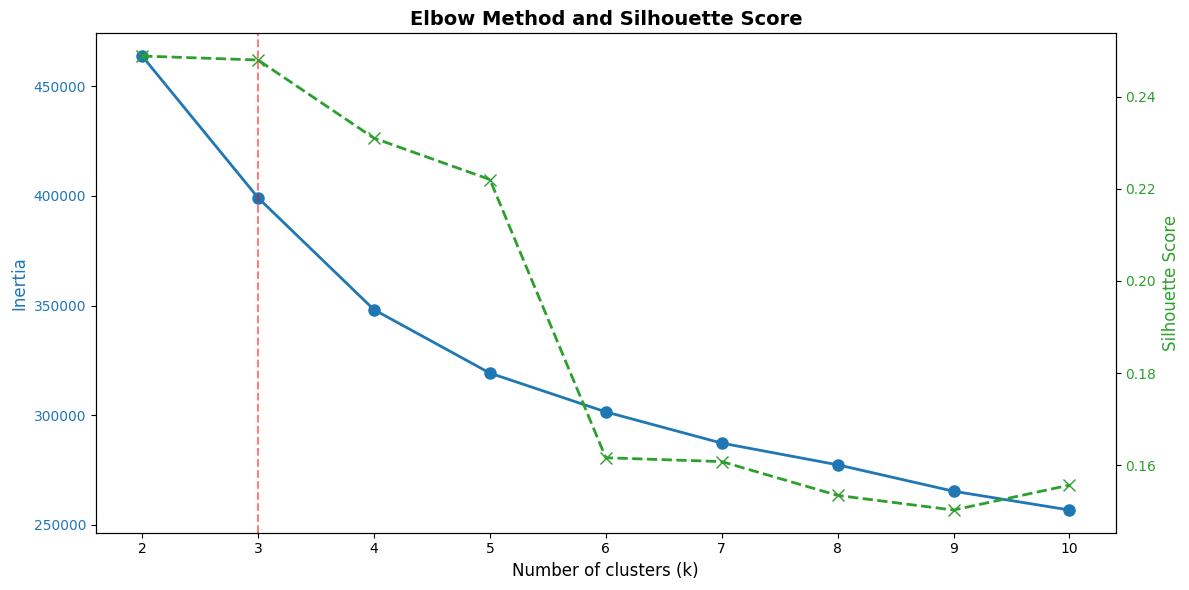


Results summary:


,k,inertia,silhouette
0,2,463812.368585,0.248794
1,3,399150.100132,0.247934
2,4,348100.775996,0.230982
3,5,319169.585163,0.222001
4,6,301469.827522,0.161632
5,7,287224.216777,0.160800
6,8,277338.192515,0.153462
7,9,265282.078855,0.150292
8,10,256710.094551,0.155696


In [34]:
inertias, silhouettes, results_k = clust.elbow_and_silhouette(
    info_clustering, 
    max_k=10, 
    exclude_cols=excluded_cols,
    random_state=42
)

print("\nResults summary:")
results_k